<big>Zadanie 1 Metoda Gaussa-Jordana</big>

<p>Napisz i sprawdź funkcję rozwiązującą układ równań liniowych n × n metodą Gaussa-Jordana z częściowym poszukiwaniem elementu wiodącego. Dla dziesięciu różnych rozmiarów macierzy współczynników większych niż 500 × 500 porównaj czasy działania
zaimplementowanej funkcji z czasami uzyskanymi dla wybranych funkcji bibliotecznych.</p>

In [3]:
import matplotlib.pyplot as plt
from random import random
from time import time
import numpy as np
from copy import deepcopy

In [4]:
## 
def gauss_jordan_method(M):
    n = len(M)

    for i in range(n):
        p_index = i

        for j in range(i+1, n):
            if abs(M[p_index][i]) < abs(M[j][i]):
                p_index = j
        if M[p_index][i] == 0: raise ValueError("Wrong matrix")

        M[i], M[p_index] = M[p_index], M[i]

        pivot = M[i][i]
        for j in range(i, n+1): 
            M[i][j] /= pivot

        for row in range(n):
            if row != i:
                scal_fact = M[row][i]
                for col in range(i, n+1):
                    M[row][col] -= scal_fact * M[i][col]

    
    return [M[i][n] for i in range(n)]

In [5]:
#generowanie macierzy
def generate_system(n):
    matrix = [[random() for _ in range(n)] for _ in range(n)]
    free_vars = [random() for _ in range(n)]
    connected = [row + [free] for row, free in zip(matrix, free_vars)]
    
    return matrix, free_vars, connected

In [6]:
##porównywanie czasu i scisłości obliczeń
def compare():    
    my_times = []
    np_times = []
    differs = []

    n = 470
    for i in range(10):
        n += 30
        A, B, M = generate_system(n)

        start_time = time()
        my_solution = gauss_jordan_method(M)
        end_time = time()
        
        my_times.append(end_time - start_time)

        start_time = time()
        np_solution = np.linalg.solve(A, B)
        end_time = time()

        max_diff = np.max(np.abs(np.array(my_solution) - np_solution))

        differs.append(max_diff)
        np_times.append(end_time - start_time)

    return my_times, np_times, differs

my_times, np_times, differs = compare()

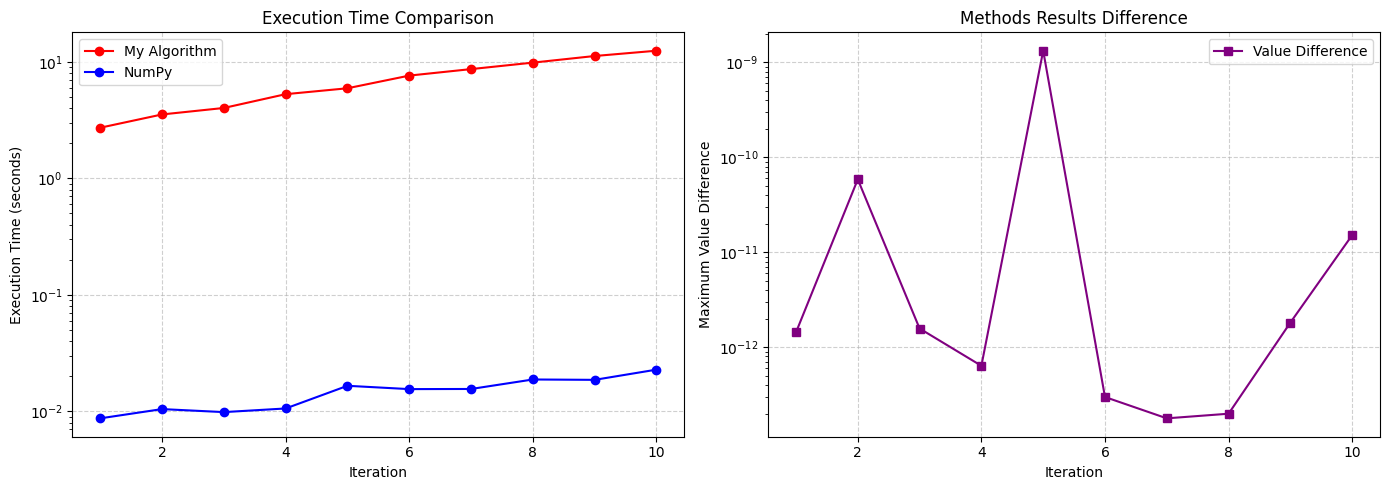

In [7]:
#generowanie wykresów
def plots(my_times, np_times):
    x_axis = list(range(1, len(my_times) + 1))
    
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    axs[0].plot(x_axis, my_times, label="My Algorithm", color="red", marker="o")
    axs[0].plot(x_axis, np_times, label="NumPy", color="blue", marker="o")

    axs[0].set_xlabel('Iteration')
    axs[0].set_ylabel('Execution Time (seconds)')
    axs[0].set_title("Execution Time Comparison")
    axs[0].set_yscale('log')
    axs[0].legend()
    axs[0].grid(True, linestyle="--", alpha=0.6)

    axs[1].plot(x_axis, differs, label="Value Difference", color="purple", marker="s")

    axs[1].set_xlabel('Iteration')
    axs[1].set_ylabel('Maximum Value Difference')
    axs[1].set_title("Methods Results Difference")
    
    #używam logarytmicznego skalowania żeby było lepej widać
    axs[1].set_yscale('log')
    axs[1].legend()
    axs[1].grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()

plots(my_times, np_times)

<big>Zadanie 2 Faktoryzacja LU</big>

LU Factorization
Napisz i przetestuj funkcję dokonującą faktoryzacji A = LU macierzy A (bez poszuki-
wania elementu wiodącego). Sprawdź poprawność wyniku obliczając ∥A − LU∥. Zadbaj
o to żeby implementacja była in-situ. Elementy macierzy L to współczynniki mnożenia umożliwiające wyzerowanie odpowiedniego współczynnika macierzy A w trakcie procesu
eliminacji

In [8]:
def LU(M):
    n = len(M)
    for j in range(n):
        for i in range(j+1, n):

            scale = M[i][j] / M[j][j]
            for k in range(j+1, n): 
                M[i][k] -= M[j][k] * scale
                
            M[i][j] = scale

In [9]:
#test 
def test_LU():
    n = 70
    for i in range(10):
        n += 30
        mat_orig = np.random.rand(n, n)
        mat_fact = deepcopy(mat_orig)
        
        start = time()
        LU(mat_fact)
        end = time()
        
        n = len(mat_orig)
        
        L = np.eye(n) 
        U = np.zeros((n, n))
        
        for i in range(n):
            for j in range(n):
                if i > j: L[i][j] = mat_fact[i][j] 
                else: U[i][j] = mat_fact[i][j] 
                        
    
        error = np.linalg.norm(np.array(mat_orig) - L @ U)
        print(f"size: {f'{n} x {n}'} | error: {error} | time: {end - start}")
    
test_LU()

size: 100 x 100 | error: 1.312642825590922e-12 | time: 0.09230804443359375
size: 130 x 130 | error: 7.2764832860051e-13 | time: 0.19180989265441895
size: 160 x 160 | error: 5.113266648168426e-12 | time: 0.3932485580444336
size: 190 x 190 | error: 2.9231995489181532e-12 | time: 0.636218786239624
size: 220 x 220 | error: 4.180547305189385e-12 | time: 0.967050313949585
size: 250 x 250 | error: 1.0860845371224472e-11 | time: 1.3880341053009033
size: 280 x 280 | error: 5.2250532417350255e-12 | time: 1.9487378597259521
size: 310 x 310 | error: 1.0094920608586999e-11 | time: 2.6639509201049805
size: 340 x 340 | error: 2.4011473209946976e-11 | time: 3.5298290252685547
size: 370 x 370 | error: 4.138277087496726e-11 | time: 4.579973220825195
